In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (12,6)

In [47]:
occupancy = pd.read_csv("../data/urbanev/occupancy.csv")
volume = pd.read_csv("../data/urbanev/volume.csv")
price = pd.read_csv("../data/urbanev/price.csv")
duration = pd.read_csv("../data/urbanev/duration.csv")

time = pd.read_csv("../data/urbanev/time.csv")

information = pd.read_csv("../data/urbanev/information.csv")

adj = pd.read_csv("../data/urbanev/adj.csv")
distance = pd.read_csv("../data/urbanev/distance.csv")
acn = pd.read_csv("../data/acn/acn_cleaned.csv")

In [4]:
timestamps = pd.to_datetime(
    time[
        [
            "year",
            "month",
            "day",
            "hour",
            "minute"
        ]
    ]
)

timestamps.head()

0   2022-06-19 00:00:00
1   2022-06-19 00:05:00
2   2022-06-19 00:10:00
3   2022-06-19 00:15:00
4   2022-06-19 00:20:00
dtype: datetime64[us]

In [5]:
total_occupancy = (
    occupancy
    .drop(columns=["timestamp"])
    .sum(axis=1)
)

In [6]:
network_df = pd.DataFrame({
    "timestamp": timestamps,
    "occupancy": total_occupancy
})

network_df.head()

,timestamp,occupancy
0,2022-06-19 00:00:00,6015
1,2022-06-19 00:05:00,6016
2,2022-06-19 00:10:00,6087
3,2022-06-19 00:15:00,6156
4,2022-06-19 00:20:00,6193


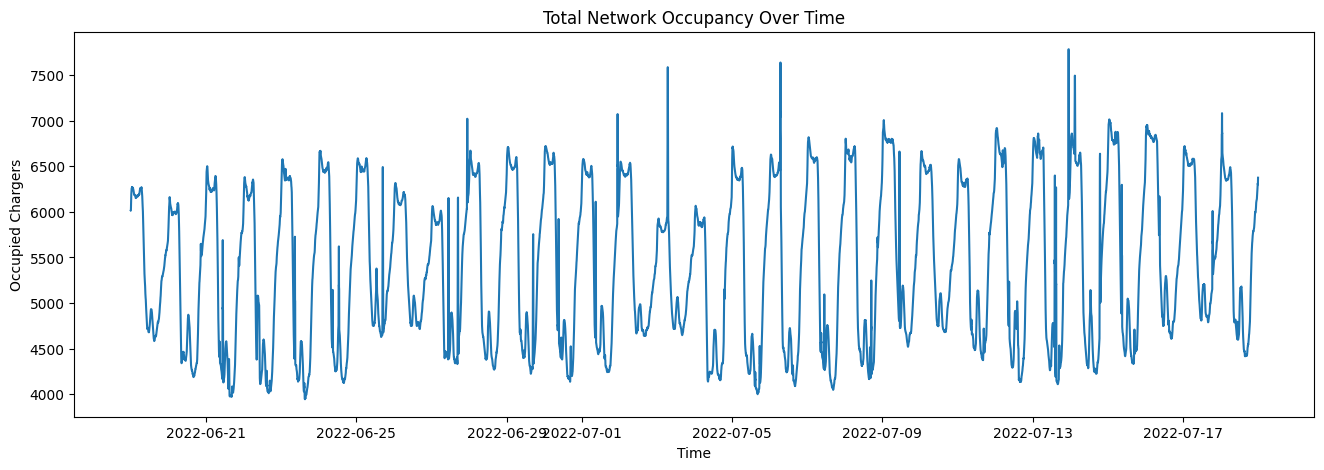

In [7]:
plt.figure(figsize=(16,5))

plt.plot(
    network_df["timestamp"],
    network_df["occupancy"]
)

plt.title("Total Network Occupancy Over Time")

plt.xlabel("Time")
plt.ylabel("Occupied Chargers")

plt.show()

In [8]:
network_df.head()

,timestamp,occupancy
0,2022-06-19 00:00:00,6015
1,2022-06-19 00:05:00,6016
2,2022-06-19 00:10:00,6087
3,2022-06-19 00:15:00,6156
4,2022-06-19 00:20:00,6193


In [9]:
network_df["hour"] = (
    network_df["timestamp"]
    .dt.hour
)

In [10]:
hourly_demand = (
    network_df
    .groupby("hour")["occupancy"]
    .mean()
)

hourly_demand

hour
0     6470.825000
1     6527.577778
2     6427.425000
3     6390.197222
4     6377.175000
5     6408.475000
6     6445.141667
7     5872.344444
8     5015.327778
9     4749.866667
10    4551.769444
11    4489.152778
12    4815.544444
13    4834.058333
14    4526.347222
15    4360.902778
16    4385.969444
17    4480.677778
18    4625.211111
19    5095.950000
20    5432.452778
21    5638.855556
22    5869.366667
23    6044.700000
Name: occupancy, dtype: float64

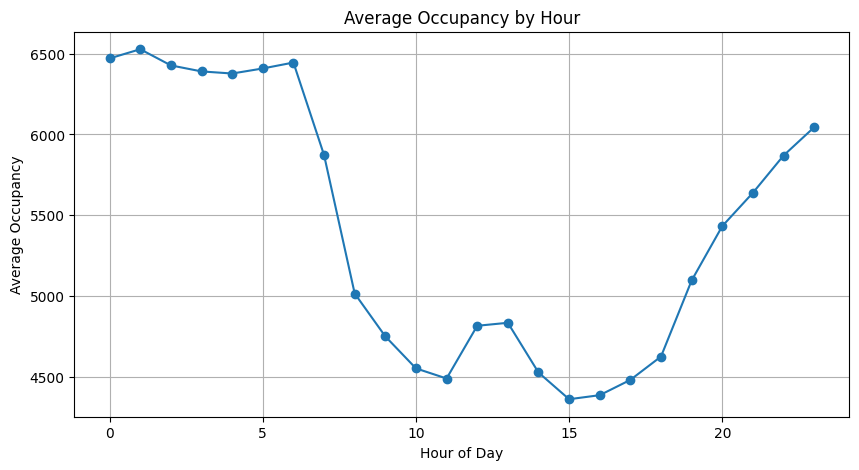

In [11]:
plt.figure(figsize=(10,5))

hourly_demand.plot(
    marker="o"
)

plt.title(
    "Average Occupancy by Hour"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")

plt.grid(True)

plt.show()

## Insight: Hourly Demand Pattern

Charging demand exhibits strong intra-day seasonality.

Peak occupancy occurs during the early hours of the day, exceeding 6500 occupied chargers, while minimum occupancy falls below 4400 chargers during afternoon periods.

The substantial variation in demand suggests that dynamic pricing can be used to redistribute charging load and improve network utilization.

In [12]:
network_df["day_name"] = (
    network_df["timestamp"]
    .dt.day_name()
)

In [13]:
daily_pattern = (
    network_df
    .groupby("day_name")["occupancy"]
    .mean()
)

In [14]:
daily_pattern = daily_pattern.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

daily_pattern

day_name
Monday       5302.912500
Tuesday      5320.463542
Wednesday    5361.555556
Thursday     5364.876736
Friday       5413.382812
Saturday     5606.937500
Sunday       5502.143056
Name: occupancy, dtype: float64

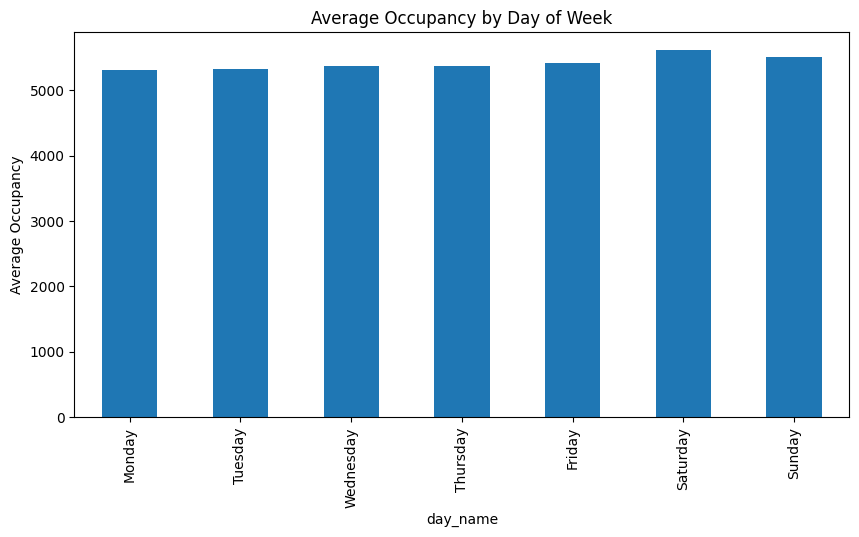

In [15]:
plt.figure(figsize=(10,5))

daily_pattern.plot(
    kind="bar"
)

plt.title(
    "Average Occupancy by Day of Week"
)

plt.ylabel(
    "Average Occupancy"
)

plt.show()

In [16]:
avg_grid_occupancy = (
    occupancy
    .drop(columns=["timestamp"])
    .mean()
    .sort_values(ascending=False)
)

avg_grid_occupancy.head(10)

1167    138.049653
703      98.767014
1049     91.651505
1137     91.193171
335      90.076736
519      80.029630
513      79.133681
1011     78.168866
526      77.911806
332      74.242245
dtype: float64

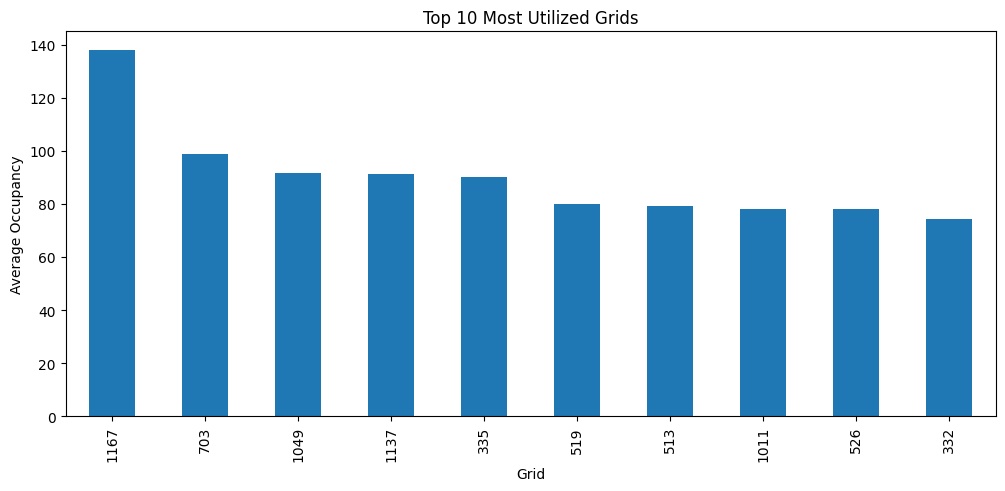

In [17]:
top10 = avg_grid_occupancy.head(10)

plt.figure(figsize=(12,5))

top10.plot(kind="bar")

plt.title(
    "Top 10 Most Utilized Grids"
)

plt.xlabel("Grid")
plt.ylabel("Average Occupancy")

plt.show()

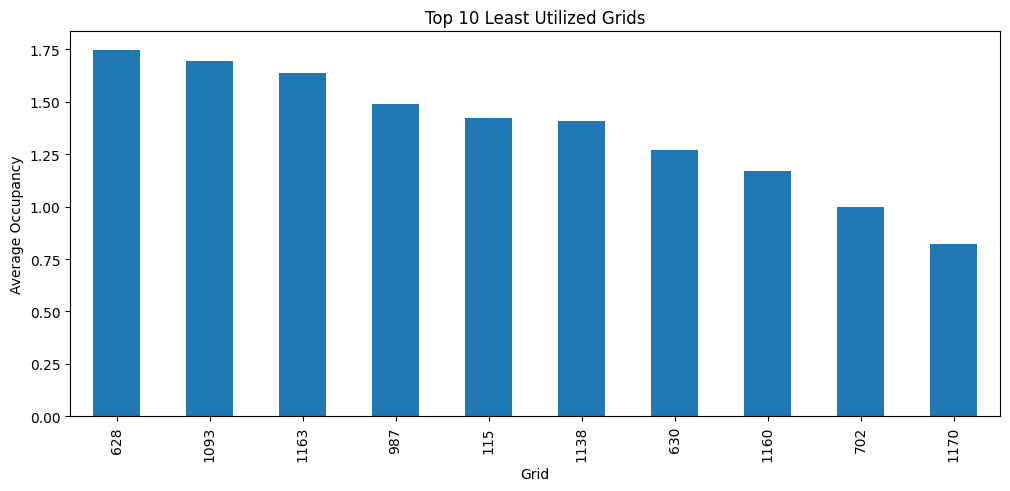

In [18]:
bottom10 = avg_grid_occupancy.tail(10)

plt.figure(figsize=(12,5))

bottom10.plot(kind="bar")

plt.title(
    "Top 10 Least Utilized Grids"
)

plt.xlabel("Grid")
plt.ylabel("Average Occupancy")

plt.show()

In [19]:
avg_grid_occupancy = (
    occupancy
    .drop(columns=["timestamp"])
    .mean()
    .reset_index()
)

avg_grid_occupancy.columns = [
    "grid",
    "avg_occupancy"
]

avg_grid_occupancy["grid"] = (
    avg_grid_occupancy["grid"]
    .astype(int)
)

avg_grid_occupancy.head()

,grid,avg_occupancy
0,102,16.586921
1,105,13.867824
2,107,18.224074
3,108,13.744560
4,109,6.224190


In [20]:
grid_analysis = avg_grid_occupancy.merge(
    information,
    on="grid",
    how="left"
)

grid_analysis.head()

,grid,avg_occupancy,num,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,102,16.586921,1,30,3,27,0.71,114.1030,22.54041,0,0
1,105,13.867824,3,93,0,93,0.77,114.1208,22.55127,0,0
2,107,18.224074,5,88,2,86,0.89,114.1304,22.54486,0,0
3,108,13.744560,6,39,0,39,1.26,114.1315,22.55403,0,0
4,109,6.224190,7,39,0,39,3.15,114.1430,22.56388,0,0


In [21]:
grid_analysis[
    [
        "avg_occupancy",
        "count",
        "fast_count",
        "slow_count",
        "area",
        "CBD",
        "dynamic_pricing"
    ]
].corr()

,avg_occupancy,count,fast_count,slow_count,area,CBD,dynamic_pricing
avg_occupancy,1.000000,0.918630,0.417371,0.829305,0.014527,-0.050414,0.323263
count,0.918630,1.000000,0.259988,0.959478,-0.010461,0.046948,0.207953
fast_count,0.417371,0.259988,1.000000,-0.022641,0.070085,-0.161820,0.500271
slow_count,0.829305,0.959478,-0.022641,1.000000,-0.031283,0.095829,0.069315
area,0.014527,-0.010461,0.070085,-0.031283,1.000000,-0.194510,0.087979
CBD,-0.050414,0.046948,-0.161820,0.095829,-0.194510,1.000000,-0.095465
dynamic_pricing,0.323263,0.207953,0.500271,0.069315,0.087979,-0.095465,1.000000


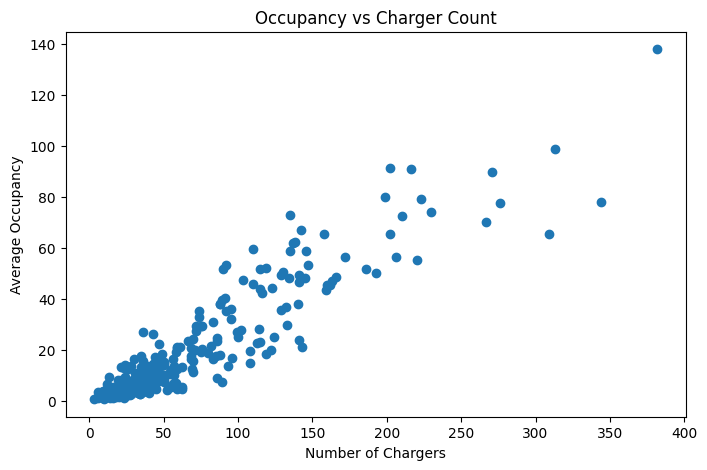

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    grid_analysis["count"],
    grid_analysis["avg_occupancy"]
)

plt.xlabel("Number of Chargers")
plt.ylabel("Average Occupancy")

plt.title(
    "Occupancy vs Charger Count"
)

plt.show()

In [24]:
grid_analysis.groupby(
    "CBD"
)["avg_occupancy"].mean()

CBD
0    22.571298
1    19.905076
Name: avg_occupancy, dtype: float64

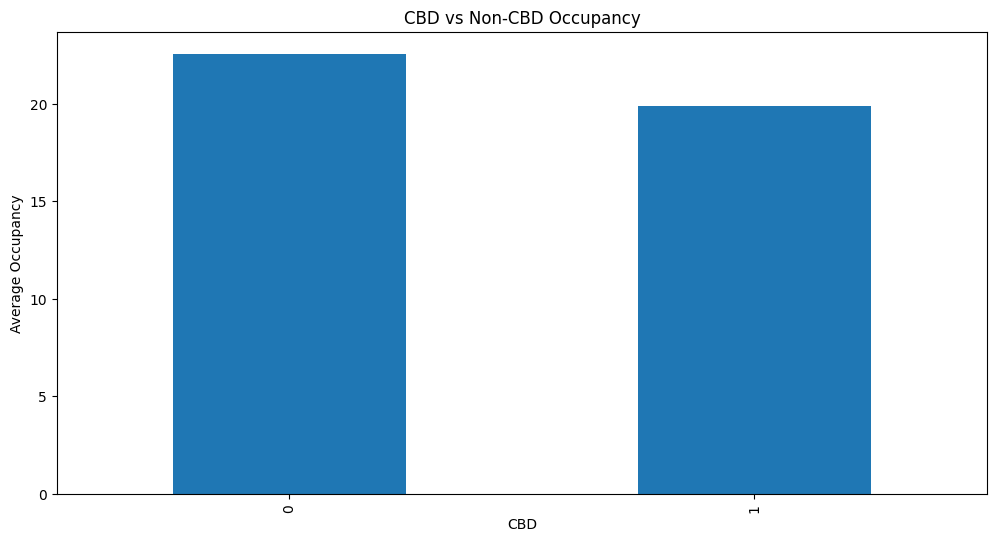

In [25]:
grid_analysis.groupby(
    "CBD"
)["avg_occupancy"].mean().plot(
    kind="bar"
)

plt.title(
    "CBD vs Non-CBD Occupancy"
)

plt.ylabel(
    "Average Occupancy"
)

plt.show()

In [26]:
avg_price = (
    price
    .drop(columns=["timestamp"])
    .mean(axis=1)
)

In [27]:
pricing_df = pd.DataFrame({
    "occupancy": total_occupancy,
    "price": avg_price
})

In [28]:
pricing_df.corr()

,occupancy,price
occupancy,1.000000,-0.875036
price,-0.875036,1.000000


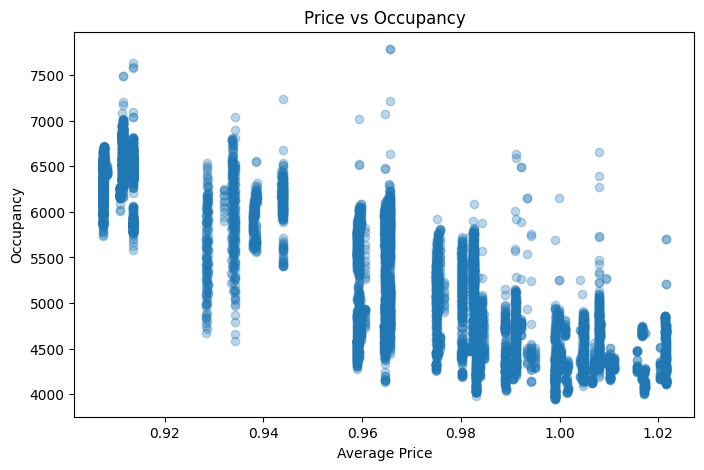

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(
    pricing_df["price"],
    pricing_df["occupancy"],
    alpha=0.3
)

plt.xlabel("Average Price")
plt.ylabel("Occupancy")

plt.title(
    "Price vs Occupancy"
)

plt.show()

## Insight: Price Elasticity

A strong negative correlation (-0.875) exists between charging price and network occupancy.

This suggests that charging demand is highly responsive to pricing signals, validating the use of dynamic pricing as a mechanism to manage congestion and improve charger utilization.

In [30]:
adj.set_index(adj.columns[0], inplace=True)

neighbors_1167 = (
    adj.loc[1167]
    [adj.loc[1167] == 1]
    .index
    .tolist()
)

neighbors_1167

['123', '124', '773', '974', '1138', '1164', '1166', '1167']

In [31]:
len(neighbors_1167)

8

In [32]:
grid_series = occupancy["1167"]

In [33]:
neighbor_series = (
    occupancy[
        [str(x) for x in neighbors_1167]
    ]
    .mean(axis=1)
)

In [34]:
grid_series.corr(
    neighbor_series
)

np.float64(0.9865663975989882)

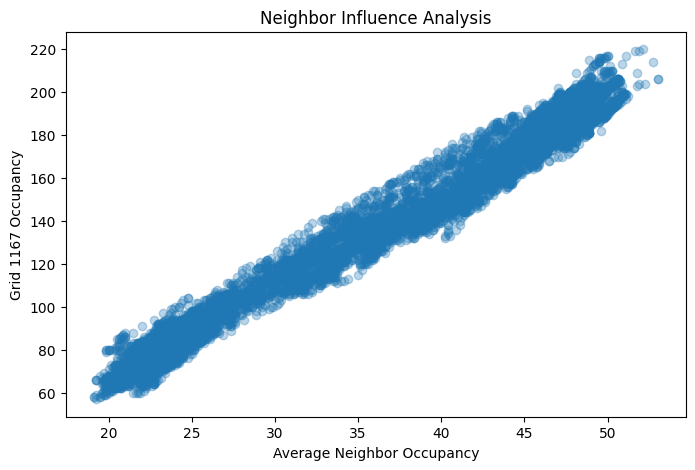

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    neighbor_series,
    grid_series,
    alpha=0.3
)

plt.xlabel(
    "Average Neighbor Occupancy"
)

plt.ylabel(
    "Grid 1167 Occupancy"
)

plt.title(
    "Neighbor Influence Analysis"
)

plt.show()

In [36]:
correlations = []

adj_copy = adj.copy()

for grid in adj_copy.index:

    neighbors = (
        adj_copy.loc[grid]
        [adj_copy.loc[grid] == 1]
        .index
        .tolist()
    )

    # remove self if present
    neighbors = [
        n for n in neighbors
        if str(n) != str(grid)
    ]

    if len(neighbors) == 0:
        continue

    try:

        grid_series = occupancy[str(grid)]

        neighbor_series = (
            occupancy[
                [str(n) for n in neighbors]
            ]
            .mean(axis=1)
        )

        corr = grid_series.corr(
            neighbor_series
        )

        correlations.append(corr)

    except:
        pass

In [37]:
corr_df = pd.DataFrame({
    "neighbor_corr": correlations
})

corr_df.describe()

,neighbor_corr
count,240.000000
mean,0.340592
std,0.392618
min,-0.678364
25%,0.047486
50%,0.365890
75%,0.672509
max,0.953811


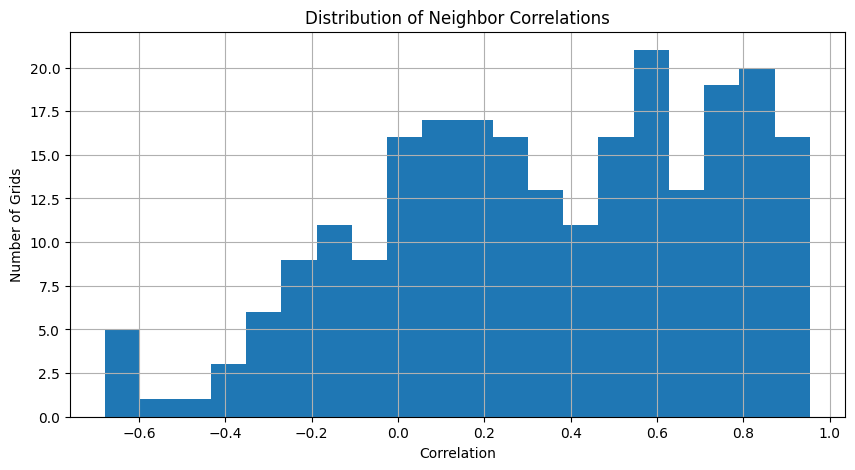

In [38]:
plt.figure(figsize=(10,5))

corr_df["neighbor_corr"].hist(
    bins=20
)

plt.title(
    "Distribution of Neighbor Correlations"
)

plt.xlabel(
    "Correlation"
)

plt.ylabel(
    "Number of Grids"
)

plt.show()

In [39]:
corr_df["neighbor_corr"].mean()

np.float64(0.3405915854323408)

In [40]:
corr_df.sort_values(
    "neighbor_corr",
    ascending=False
).head(10)

,neighbor_corr
151,0.953811
136,0.940325
28,0.939682
235,0.935370
135,0.932921
124,0.932429
150,0.924451
125,0.913580
168,0.908066
155,0.898338


In [41]:
corr_df.sort_values(
    "neighbor_corr",
    ascending=True
).head(10)

,neighbor_corr
82,-0.678364
131,-0.668593
35,-0.632033
52,-0.611173
201,-0.609135
187,-0.561738
230,-0.467768
196,-0.394383
40,-0.390135
215,-0.361878


## Insight: Spatial Heterogeneity

Neighbor influence varies significantly across charging grids.

While certain grids exhibit extremely strong spatial dependence (correlations above 0.9), others display weak or even negative relationships with neighboring demand.

This suggests that a single forecasting strategy may not be optimal for all locations.

The Demand Prediction Agent should incorporate neighbor-aware features while allowing the model to learn grid-specific behavior.

In [42]:
corr_df["grid"] = avg_grid_occupancy["grid"].values[:len(corr_df)]

spatial_analysis = corr_df.merge(
    information,
    on="grid",
    how="left"
)

spatial_analysis.head()

,neighbor_corr,grid,num,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,0.000663,102,1,30,3,27,0.71,114.1030,22.54041,0,0
1,-0.090473,105,3,93,0,93,0.77,114.1208,22.55127,0,0
2,0.179113,107,5,88,2,86,0.89,114.1304,22.54486,0,0
3,0.559759,108,6,39,0,39,1.26,114.1315,22.55403,0,0
4,0.163322,109,7,39,0,39,3.15,114.1430,22.56388,0,0


In [43]:
spatial_analysis.groupby(
    "dynamic_pricing"
)["neighbor_corr"].mean()

dynamic_pricing
0    0.333461
1    0.364020
Name: neighbor_corr, dtype: float64

In [44]:
spatial_analysis.groupby(
    "CBD"
)["neighbor_corr"].mean()

CBD
0    0.370422
1    0.254951
Name: neighbor_corr, dtype: float64

# Executive Summary

## Temporal Findings

- Charging demand exhibits strong daily seasonality.
- Hour of day is a significantly stronger predictor than day of week.
- Weekend demand is only marginally higher than weekday demand.

## Infrastructure Findings

- Charger count is strongly associated with utilization (correlation ≈ 0.92).
- Slow charger availability exhibits stronger correlation with occupancy than fast charger availability.
- CBD status has limited impact on average utilization.

## Pricing Findings

- Price and occupancy exhibit a strong negative correlation (≈ -0.88).
- Charging demand appears highly responsive to pricing signals.
- Dynamic pricing is therefore a viable congestion-management mechanism.

## Spatial Findings

- Spatial dependence varies considerably across charging grids.
- Certain grids exhibit extremely strong neighbor influence (>0.9 correlation), while others show weak or negative spatial relationships.
- Non-CBD grids display higher average spatial dependence than CBD grids.
- Neighbor-aware forecasting features should be incorporated into the Demand Prediction Agent.

# ACN Behavioral Analysis

This section analyzes user-level charging behavior using the ACN dataset.

The objective is to understand charging duration, energy consumption patterns, session arrival behavior, and customer charging characteristics that can inform tariff design and revenue optimization.

## Session Duration Analysis

This analysis examines how long charging stations remain occupied by vehicles.

Understanding session duration is important for charger utilization optimization and dynamic tariff design.

In [50]:
acn["session_duration_hours"].describe()

count    14999.000000
mean         5.923631
std          6.459457
min          0.087500
25%          2.025139
50%          4.764167
75%          8.729722
max        245.269167
Name: session_duration_hours, dtype: float64

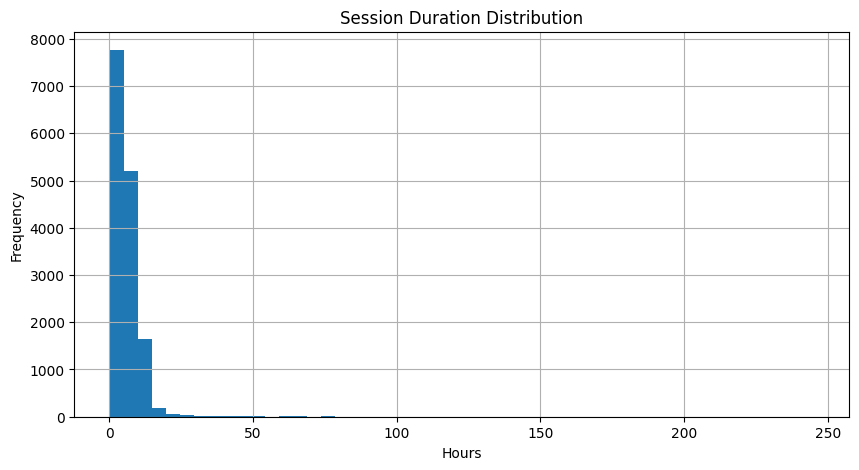

In [51]:
plt.figure(figsize=(10,5))

acn["session_duration_hours"].hist(
    bins=50
)

plt.title("Session Duration Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")

plt.show()

In [52]:
acn["charging_duration_hours"].describe()

count    14991.000000
mean         3.236411
std          3.185251
min         -0.689444
25%          1.271806
50%          2.241667
75%          4.244444
max        104.428333
Name: charging_duration_hours, dtype: float64

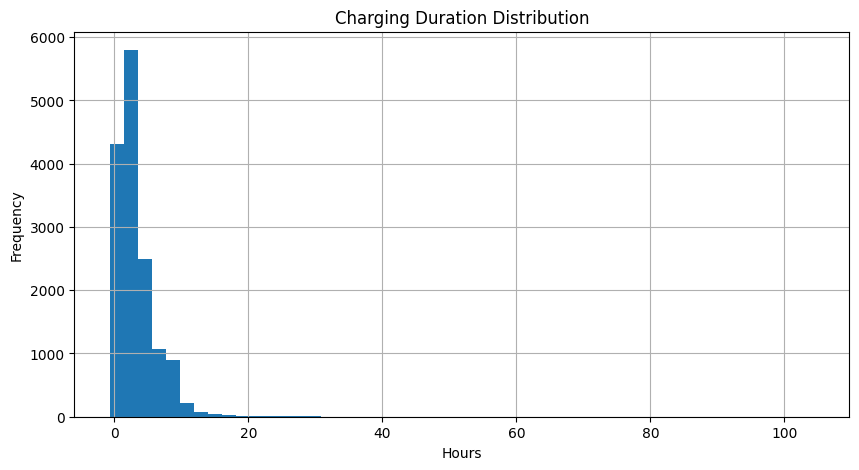

In [53]:
plt.figure(figsize=(10,5))

acn["charging_duration_hours"].hist(
    bins=50
)

plt.title("Charging Duration Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")

plt.show()

In [57]:
acn["idle_time_hours"] = (
    acn["session_duration_hours"]
    - acn["charging_duration_hours"]
)

acn["idle_time_hours"].describe()

count    14991.000000
mean         2.689698
std          5.395779
min         -0.016667
25%          0.001389
50%          0.739722
75%          4.186528
max        156.121389
Name: idle_time_hours, dtype: float64

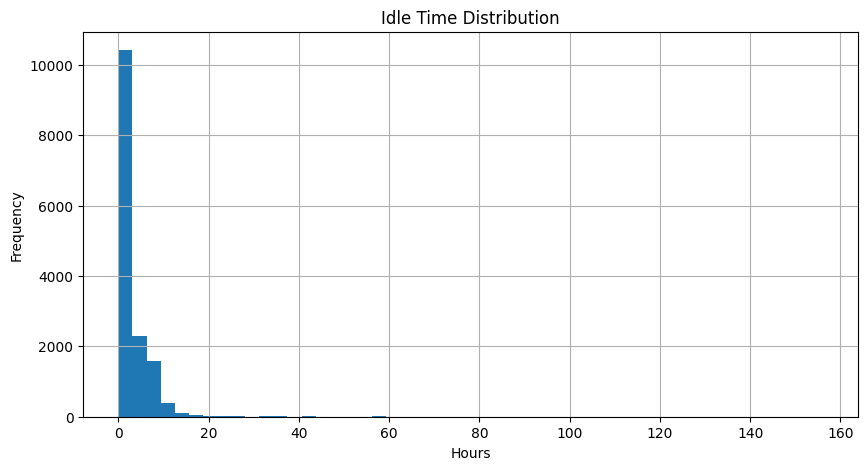

In [56]:
plt.figure(figsize=(10,5))

acn["idle_time_hours"].hist(
    bins=50
)

plt.title("Idle Time Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")

plt.show()

In [58]:
arrival_pattern = (
    acn.groupby("hour")
    .size()
)

arrival_pattern

hour
0.0      766
1.0      878
2.0      712
3.0      576
4.0      376
5.0      266
6.0      138
7.0       92
8.0       67
9.0       26
10.0      24
11.0     137
12.0      76
13.0     396
14.0    1088
15.0    2572
16.0    2038
17.0    1017
18.0     619
19.0     705
20.0     717
21.0     529
22.0     543
23.0     641
dtype: int64

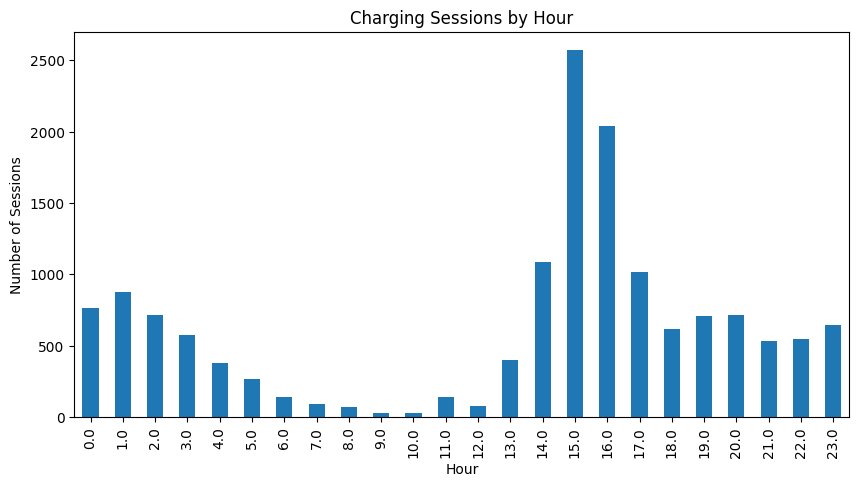

In [59]:
plt.figure(figsize=(10,5))

arrival_pattern.plot(
    kind="bar"
)

plt.title("Charging Sessions by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Sessions")

plt.show()

In [60]:
acn["kWhDelivered"].describe()

count    14999.000000
mean         9.002466
std          7.055848
min          0.501000
25%          4.008500
50%          7.435000
75%         13.204000
max         69.373000
Name: kWhDelivered, dtype: float64

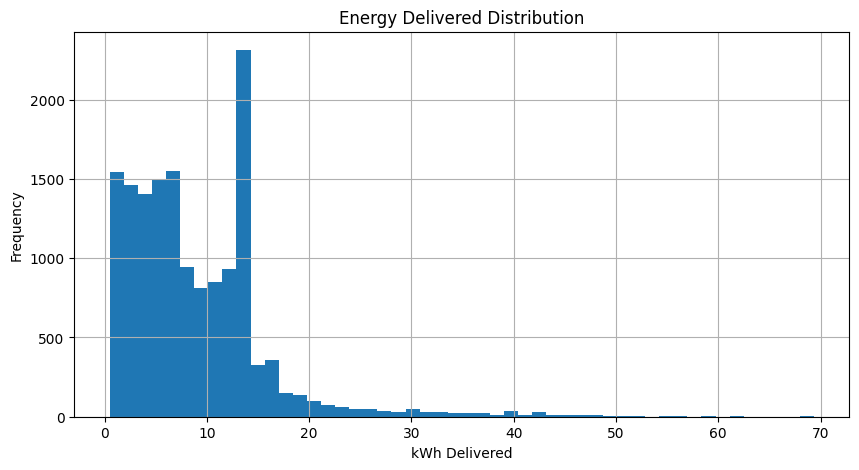

In [61]:
plt.figure(figsize=(10,5))

acn["kWhDelivered"].hist(
    bins=50
)

plt.title("Energy Delivered Distribution")

plt.xlabel("kWh Delivered")

plt.ylabel("Frequency")

plt.show()

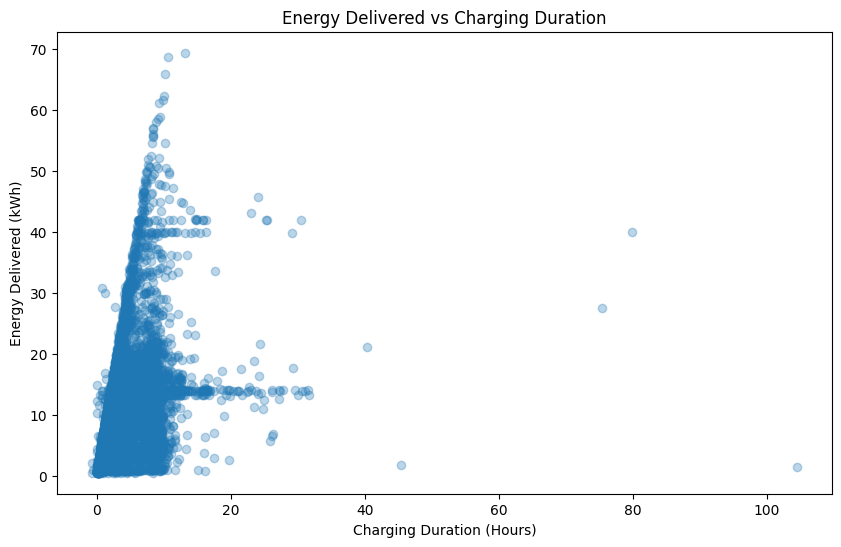

In [62]:
plt.figure(figsize=(10,6))

plt.scatter(
    acn["charging_duration_hours"],
    acn["kWhDelivered"],
    alpha=0.3
)

plt.xlabel("Charging Duration (Hours)")
plt.ylabel("Energy Delivered (kWh)")

plt.title(
    "Energy Delivered vs Charging Duration"
)

plt.show()

In [63]:
(acn["charging_duration_hours"] < 0).sum()

np.int64(18)

In [64]:
acn = acn[
    acn["charging_duration_hours"] >= 0
]

In [65]:
acn["kWhDelivered"].corr(
    acn["charging_duration_hours"]
)

np.float64(0.49660238119781713)

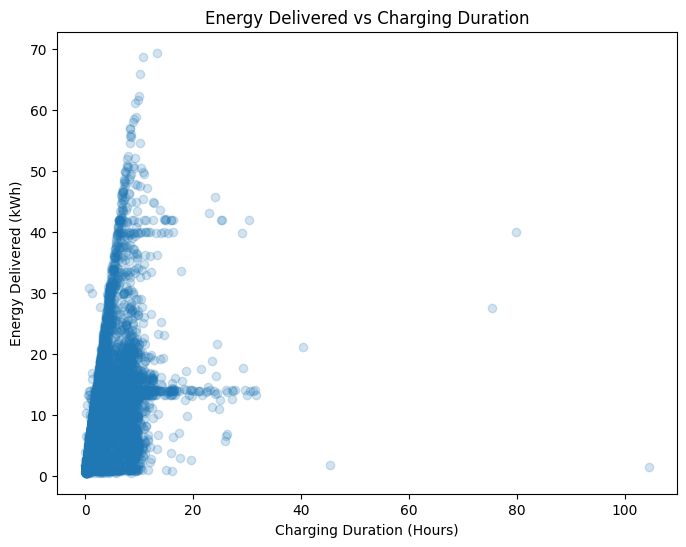

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(
    acn["charging_duration_hours"],
    acn["kWhDelivered"],
    alpha=0.2
)

plt.title(
    "Energy Delivered vs Charging Duration"
)

plt.xlabel(
    "Charging Duration (Hours)"
)

plt.ylabel(
    "Energy Delivered (kWh)"
)

plt.show()

## ACN Behavioral Insights

- Average session duration is approximately 5.9 hours.
- Average charging duration is approximately 3.2 hours.
- Vehicles remain connected for roughly 2.7 hours after charging completion on average.
- Significant charging demand occurs during afternoon hours, particularly between 3 PM and 5 PM.
- Average energy delivered per session is approximately 9 kWh.
- Energy delivered exhibits a moderate positive correlation (≈0.50) with charging duration.
- Idle occupancy represents a major opportunity for utilization improvement through pricing incentives and idle-fee mechanisms.